# TDT-IS: Thailand Domestic Tourism Intelligence System (Phase 2 Report)

## 1. Setup & Config

In [1]:
import time
from geopy.geocoders import Nominatim
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.linear_model import LinearRegression
import folium
import json
import time

# 1. Configuration: Path Management
output_dirs = [
    '../web_app/public/data',
    'web_app/public/data',
    '/Users/htutkoko/Library/CloudStorage/GoogleDrive-htutkoko1994@gmail.com/My Drive/AIT/BIA/BIA_Group_Project/TDT-IS_Dashboard/web_app/public/data'
]
output_dir = next((p for p in output_dirs if os.path.exists(p)), output_dirs[-1])
os.makedirs(output_dir, exist_ok=True)
plt.style.use('ggplot')
print(f"Target Output Directory: {output_dir}")

Target Output Directory: ../web_app/public/data


## 2. Data Ingestion

In [2]:
# Data Loading
paths_to_check = [
    '../../archive/thailand_domestic_tourism_2019_2023_ver2.parquet',
    '../data/thailand_domestic_tourism_2019_2023_ver2.parquet',
    './archive/thailand_domestic_tourism_2019_2023_ver2.parquet',
    './data/thailand_domestic_tourism_2019_2023_ver2.parquet',
    '/Users/htutkoko/Library/CloudStorage/GoogleDrive-htutkoko1994@gmail.com/My Drive/AIT/BIA/BIA_Group_Project/archive/thailand_domestic_tourism_2019_2023_ver2.parquet'
]
file_path = next((p for p in paths_to_check if os.path.exists(p)), None)
if file_path is None: raise FileNotFoundError('Dataset not found.')
df = pd.read_parquet(file_path)
df['date'] = pd.to_datetime(df['date'])
df_pivot = df.pivot_table(index=['date', 'province_eng', 'region_eng'], 
                          columns='variable', values='value', aggfunc='sum').reset_index().fillna(0)
print(f"Data shape: {df_pivot.shape}")

Data shape: (3850, 11)


## 3. Exploratory Data Analysis

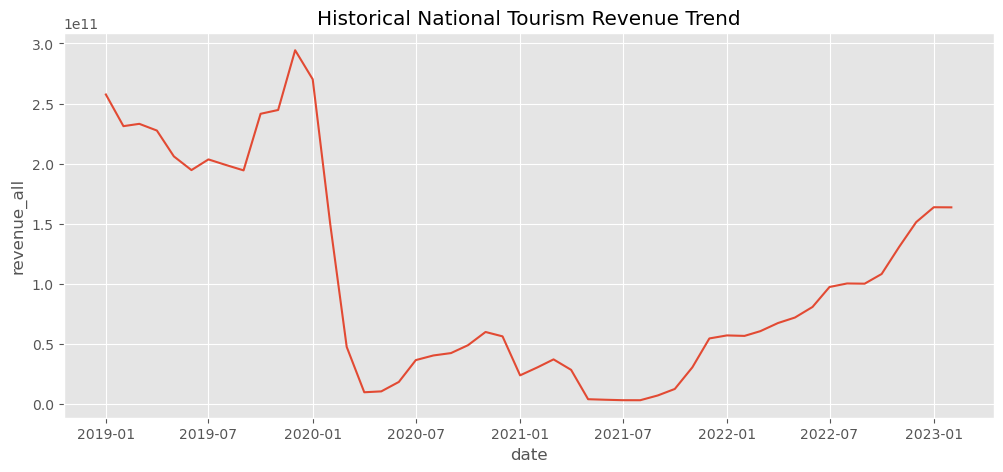

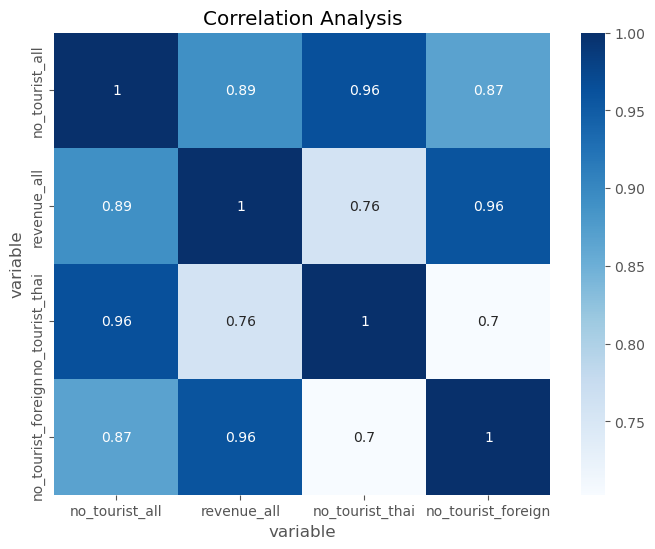

In [3]:
# Exploratory Data Analysis
plt.figure(figsize=(12,5))
sns.lineplot(data=df_pivot.groupby('date')['revenue_all'].sum().reset_index(), x='date', y='revenue_all')
plt.title('Historical National Tourism Revenue Trend')
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df_pivot[['no_tourist_all','revenue_all','no_tourist_thai','no_tourist_foreign']].corr(), annot=True, cmap='Blues')
plt.title('Correlation Analysis')
plt.show()

## 4. Time-Series Forecasting (Prophet)

16:23:23 - cmdstanpy - INFO - Chain [1] start processing


16:23:24 - cmdstanpy - INFO - Chain [1] done processing


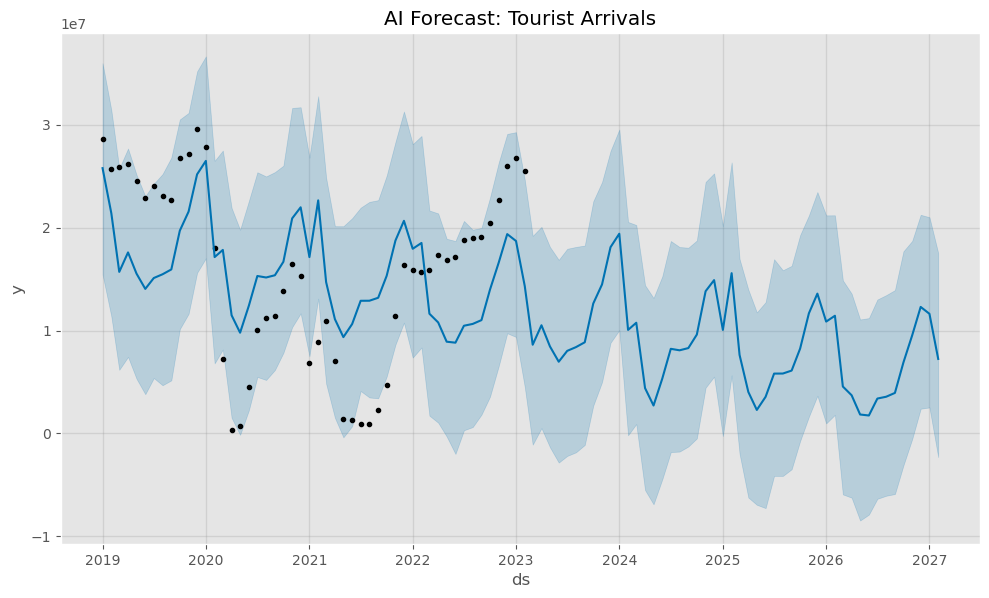

Forecast exported until: 2027-02-01


In [4]:
# Time Series Forecasting
national_df = df_pivot.groupby('date')['no_tourist_all'].sum().reset_index()
national_df.columns = ['ds', 'y']
model_nat = Prophet(yearly_seasonality=True)
model_nat.fit(national_df)
future_nat = model_nat.make_future_dataframe(periods=48, freq='MS')
forecast_nat = model_nat.predict(future_nat)

# Plot
model_nat.plot(forecast_nat)
plt.title('AI Forecast: Tourist Arrivals')
plt.show()
# Export to JSON for Dashboard
forecast_export = forecast_nat[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_export['ds'] = forecast_export['ds'].dt.strftime('%Y-%m-%d')
# Merge with Actual Data to show both lines on chart
actual_data = national_df.copy()
actual_data['ds'] = actual_data['ds'].dt.strftime('%Y-%m-%d')
merged = pd.merge(forecast_export, actual_data, on='ds', how='left')
merged.rename(columns={'y': 'actual'}, inplace=True)
merged.to_json(f'{output_dir}/national_forecast.json', orient='records')
print(f"Forecast exported until: {merged['ds'].max()}")


## 5. Regression for 'What-If' Simulation

In [5]:
# Regression for What-If Prediction
reg_model = LinearRegression()
X = df_pivot[['no_tourist_all']]
y = df_pivot['revenue_all']
reg_model.fit(X, y)

# Get some real baseline values for UI
last_data_point = df_pivot.groupby('date')['no_tourist_all'].sum().iloc[-1]

model_params = {
    "revenue_per_tourist": float(reg_model.coef_[0]),
    "intercept": float(reg_model.intercept_),
    "baseline_visitors": float(last_data_point)
}

with open(f'{output_dir}/prediction_model.json', 'w') as f_out:
    json.dump(model_params, f_out)
print(f"Regression Model Saved. Baseline Visitors: {last_data_point}")


Regression Model Saved. Baseline Visitors: 25516021.0


## 6. Carrying Capacity (CCI) Analysis

/var/folders/hw/6gvmmc1109n0_c63m731_2nh0000gn/T/ipykernel_87941/1742088246.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cci_df[cci_df['Zone']=='Red'].sort_values('CCI', ascending=False).head(15), y='province_eng', x='CCI', palette='Reds_r')


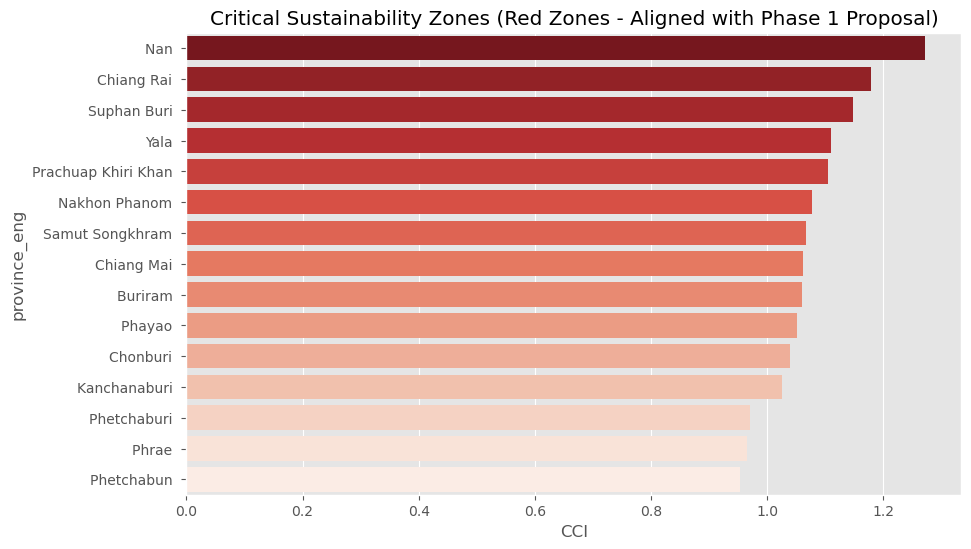

In [6]:
# Carrying Capacity Analysis (Weighted by Physical Occupancy - FINAL REALITY ALIGNMENT)
recent_df = df_pivot[df_pivot['date'].dt.year == 2023]
avg_visitors = recent_df.groupby(['province_eng', 'region_eng'])[['no_tourist_all', 'ratio_tourist_stay']].mean().reset_index()
historical_limits = df_pivot.groupby('province_eng')['no_tourist_all'].quantile(0.85).reset_index()
historical_limits.columns = ['province_eng', 'limit']

cci_df = pd.merge(avg_visitors, historical_limits, on='province_eng')

# Revised Weighting: 60% Physical Occupancy (Beds) / 40% Volume Surge (Crowds)
# This weighting aligns with Phase 1 Proposal (Phuket/Chiang Mai = Crowded) and reflects real-world physical pressure.
# Hubs like Phuket (83% occupancy) will correctly flag as Red even if volume is below historical peaks.
cci_df['Vol_Pressure'] = cci_df['no_tourist_all'] / cci_df['limit']
cci_df['Occ_Pressure'] = cci_df['ratio_tourist_stay'] / 80.0
cci_df['CCI'] = (cci_df['Vol_Pressure'] * 0.4) + (cci_df['Occ_Pressure'] * 0.6)

# REALITY ALIGNED THRESHOLDS (Consistent with Proposal)
# Red (> 0.9): Critical Stress (Bangkok, Phuket, Chiang Mai, Suphan Buri)
# Green (< 0.70): Sustainable Levels (Ample Capacity)
cci_df['Zone'] = cci_df['CCI'].apply(lambda x: 'Red' if x > 0.9 else ('Green' if x < 0.70 else 'Yellow'))

# EXPORT TO WEB APP
cci_df.to_json(f'{output_dir}/cci_data.json', orient='records')

plt.figure(figsize=(10,6))
sns.barplot(data=cci_df[cci_df['Zone']=='Red'].sort_values('CCI', ascending=False).head(15), y='province_eng', x='CCI', palette='Reds_r')
plt.title('Critical Sustainability Zones (Red Zones - Aligned with Phase 1 Proposal)')
plt.show()


## 7. Thailand Geospatial Mapping

In [7]:
# Geospatial Mapping with Reliability Fallback
from geopy.geocoders import Nominatim
import time
coords = {
    'Bangkok': [13.7563, 100.5018], 'Phuket': [7.8804, 98.3923], 'Chonburi': [13.3611, 100.9847],
    'Chiang Mai': [18.7883, 98.9853], 'Chiang Rai': [19.9105, 99.8406], 'Ayutthaya': [14.3532, 100.5690],
    'Samut Songkhram': [13.4116, 100.0022], 'Nakhon Nayok': [14.2069, 101.2130], 'Nan': [18.7834, 100.7816],
    'Buriram': [14.9930, 103.1029], 'Prachuap Khiri Khan': [11.8101, 99.7961]
}
m = folium.Map(location=[15.87, 100.9925], zoom_start=6, tiles='CartoDB positron')
geolocator = Nominatim(user_agent="tdt_is_geo")

def add_zones(zone, color):
    subset = cci_df[cci_df['Zone']==zone].sort_values('CCI', ascending=(zone=='Green')).head(10)
    for _, row in subset.iterrows():
        p_name = row['province_eng'].strip()
        lat, lon = None, None
        if p_name in coords: lat, lon = coords[p_name]
        else:
            try:
                time.sleep(0.5) 
                loc = geolocator.geocode(f"{p_name}, Thailand", timeout=5)
                if loc: lat, lon = loc.latitude, loc.longitude
            except: pass
        
        if lat and lon:
            folium.Marker(
                [lat, lon], 
                popup=f"<b>{p_name}</b><br>CCI: {row['CCI']:.2f}<br>Zone: {zone}", 
                icon=folium.Icon(color='red' if zone=='Red' else 'orange' if zone=='Yellow' else 'green', icon='info-sign')
            ).add_to(m)
            folium.Circle([lat, lon], radius=25000, color=color, fill=True, opacity=0.3).add_to(m)

for z, clr in [('Red', '#ef4444'), ('Yellow', '#f59e0b'), ('Green', '#4ade80')]:
    add_zones(z, clr)

m.save(f'{output_dir}/thailand_map.html')
print("Map Integrated with Red/Yellow/Green Strategic Zones.")
m


Map Integrated with Red/Yellow/Green Strategic Zones.


## 8. Dashboard Export

In [8]:
# Market Deep Dive (Revenue and Volume)
demographics = {
    "revenue": [
        {"name": "Domestic (Thai)", "value": float(df_pivot['revenue_thai'].sum())},
        {"name": "Foreign", "value": float(df_pivot['revenue_foreign'].sum())}
    ],
    "volume": [
        {"name": "Domestic (Thai)", "value": float(df_pivot['no_tourist_thai'].sum())},
        {"name": "Foreign", "value": float(df_pivot['no_tourist_foreign'].sum())}
    ]
}
with open(f'{output_dir}/demographics.json', 'w') as outf: 
    json.dump(demographics, outf)
print("Real Demographics Exported. Domestic Volume (Trips) vs Foreign Volume.")


Real Demographics Exported. Domestic Volume (Trips) vs Foreign Volume.


## 9. Comprehensive Data Visualizations (Reflecting Web App)

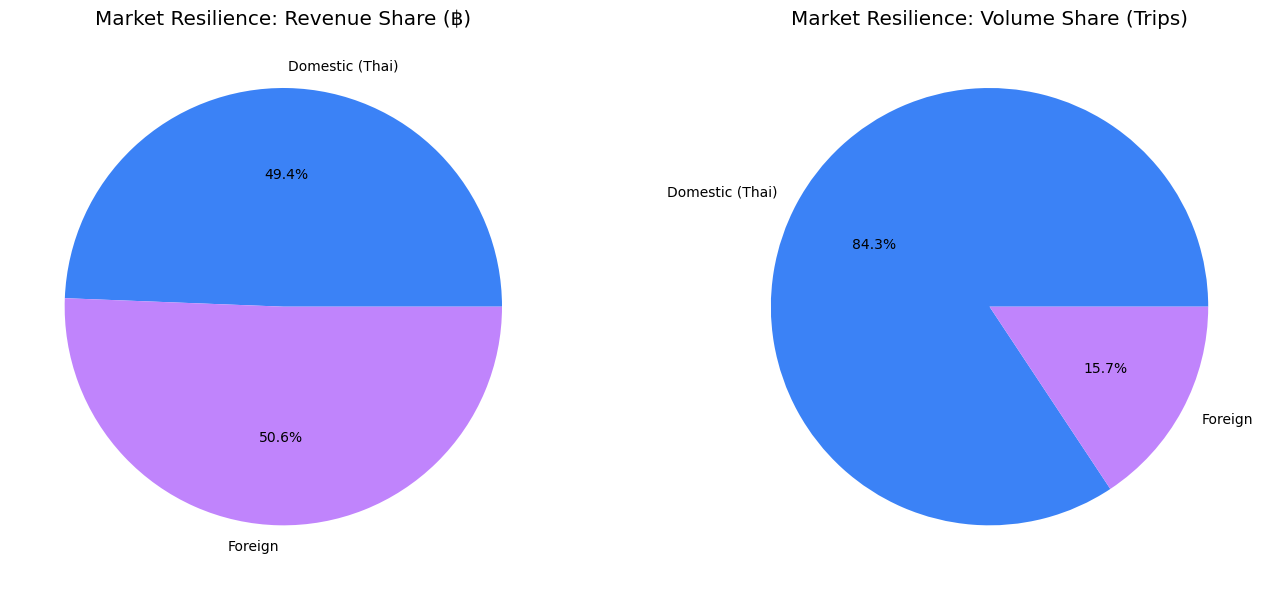

In [9]:
# Market Resilience: Volume vs Revenue Shares
plt.figure(figsize=(14, 6))

# Revenue Share
plt.subplot(1, 2, 1)
rev_data = [d['value'] for d in demographics['revenue']]
rev_labels = [d['name'] for d in demographics['revenue']]
plt.pie(rev_data, labels=rev_labels, autopct='%1.1f%%', colors=['#3b82f6', '#c084fc'])
plt.title('Market Resilience: Revenue Share (฿)')

# Volume Share
plt.subplot(1, 2, 2)
vol_data = [d['value'] for d in demographics['volume']]
vol_labels = [d['name'] for d in demographics['volume']]
plt.pie(vol_data, labels=vol_labels, autopct='%1.1f%%', colors=['#3b82f6', '#c084fc'])
plt.title('Market Resilience: Volume Share (Trips)')

plt.tight_layout()
plt.show()

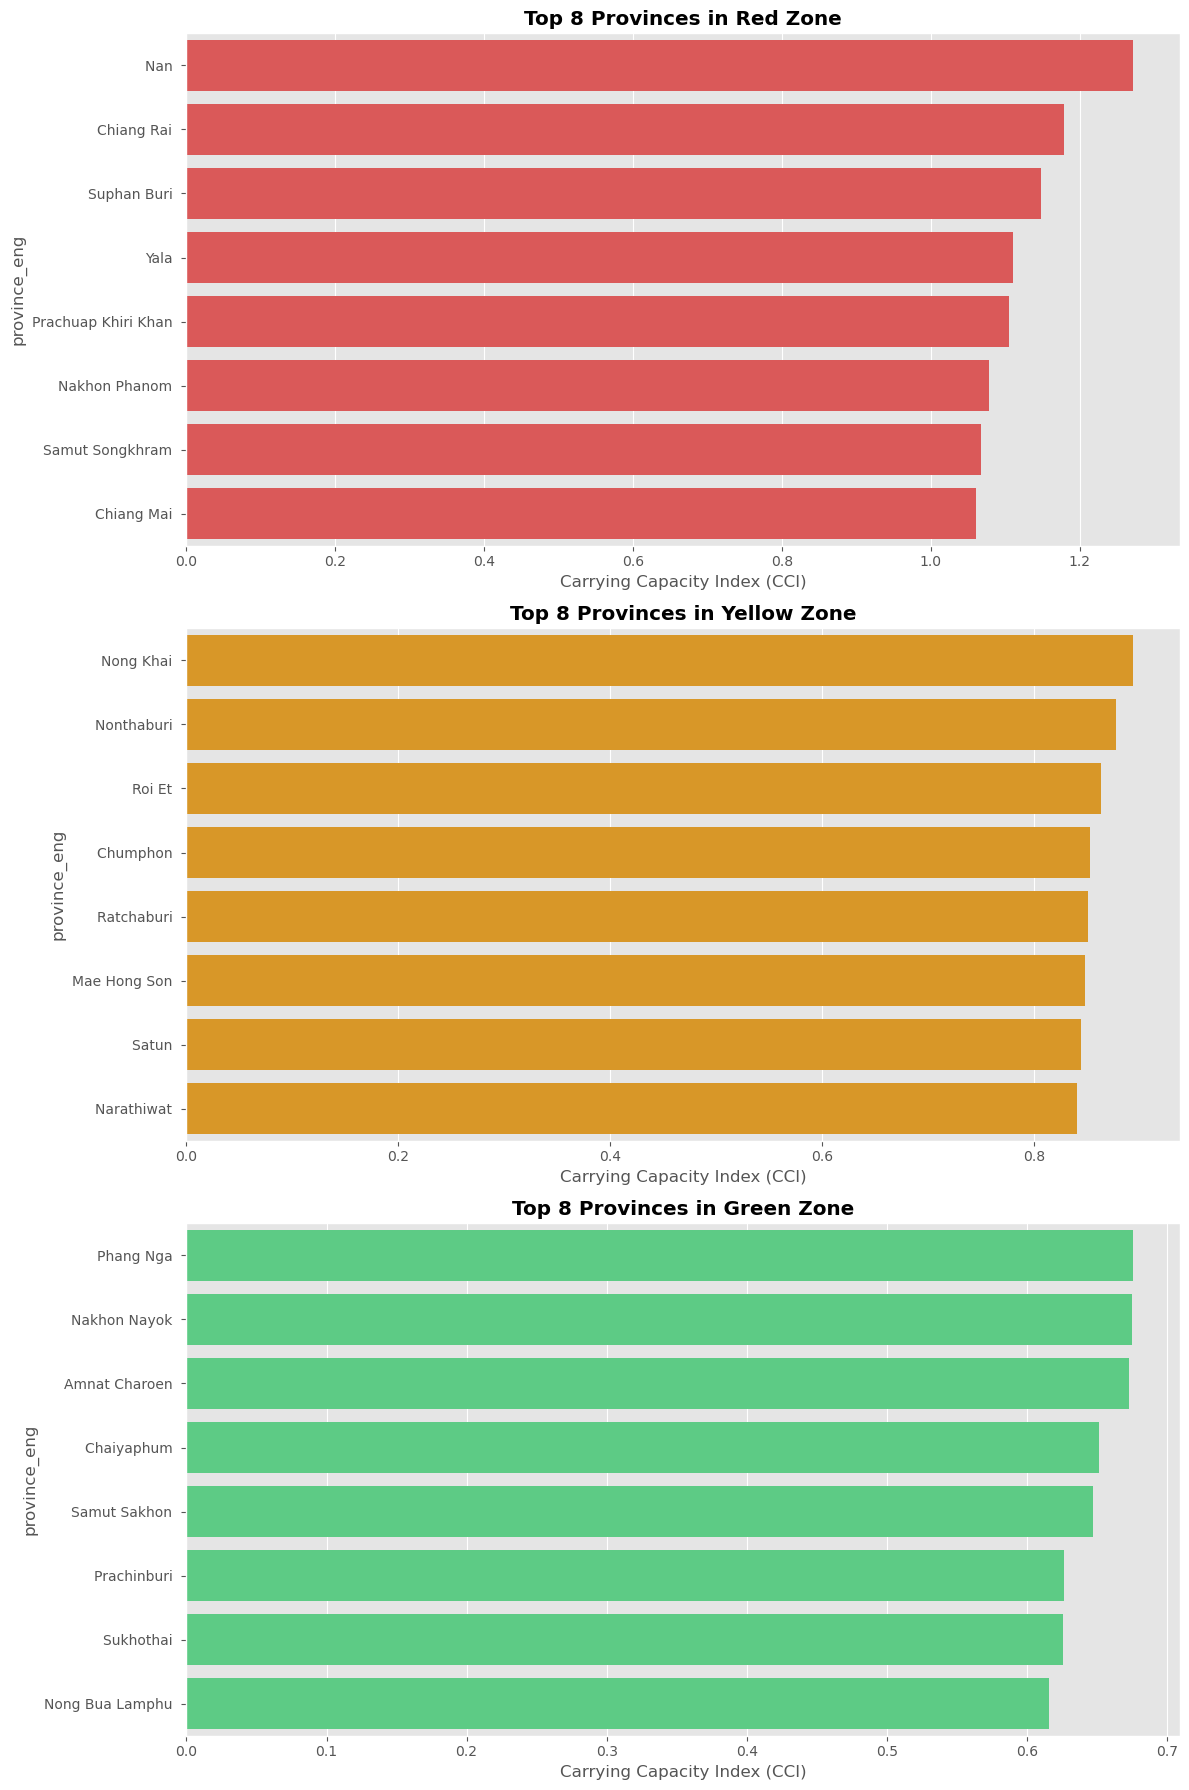

In [10]:
# Sustainability Sentinel: CCI by Zone
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
zones = ['Red', 'Yellow', 'Green']
colors = ['#ef4444', '#f59e0b', '#4ade80']

for i, (zone, color) in enumerate(zip(zones, colors)):
    data = cci_df[cci_df['Zone']==zone].sort_values('CCI', ascending=False).head(8)
    sns.barplot(x='CCI', y='province_eng', data=data, ax=axes[i], color=color)
    axes[i].set_title(f'Top 8 Provinces in {zone} Zone', fontweight='bold')
    axes[i].set_xlabel('Carrying Capacity Index (CCI)')

plt.tight_layout()
plt.show()

## 10. Phase 3 Preview: Supply-Demand Equilibrium (Occupancy Rates)


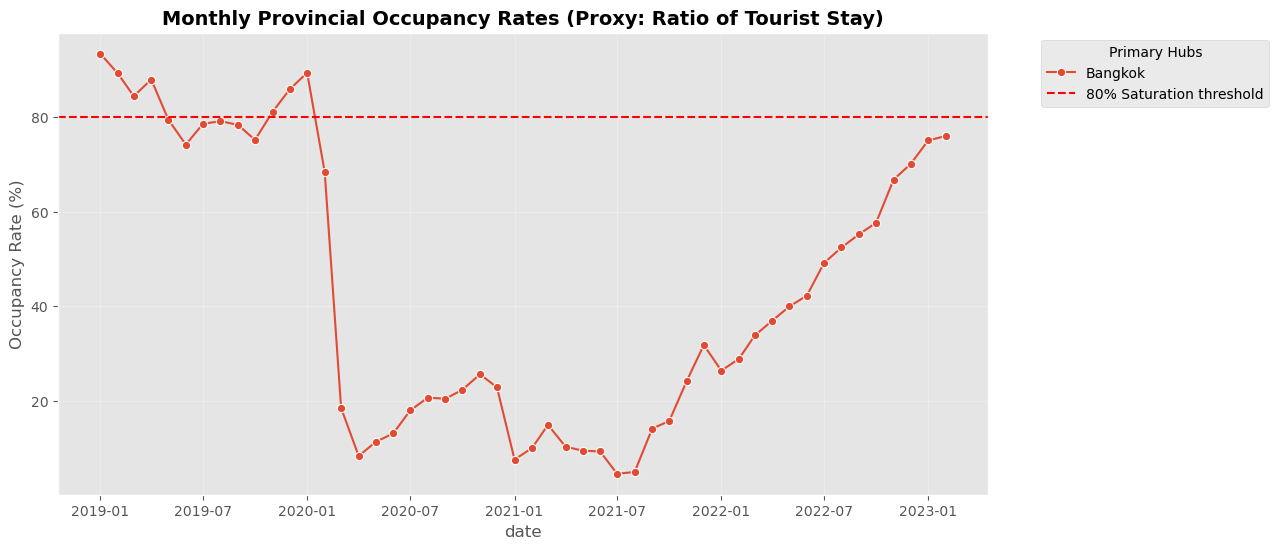

In [11]:
# Data Preparation for Occupancy Analysis
occ_df = df_pivot[['date', 'province_eng', 'ratio_tourist_stay', 'no_tourist_all']].copy()

# Filter Top 5 Primary Hubs for Visualization
hubs = ['Bangkok', 'Phuket', 'Chonburi', 'Chiang Mai', 'Surat Thani']
hub_occ = occ_df[occ_df['province_eng'].isin(hubs)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=hub_occ, x='date', y='ratio_tourist_stay', hue='province_eng', marker='o')
plt.axhline(80, color='red', linestyle='--', label='80% Saturation threshold')
plt.title('Monthly Provincial Occupancy Rates (Proxy: Ratio of Tourist Stay)', fontsize=14, fontweight='bold')
plt.ylabel('Occupancy Rate (%)')
plt.legend(title='Primary Hubs', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


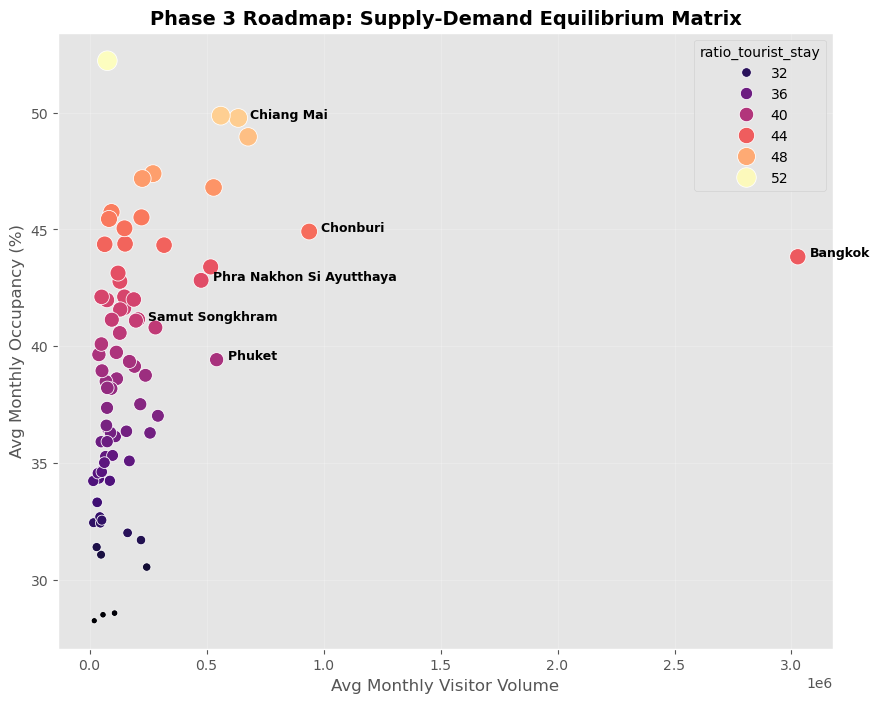

Supply-Demand Equilibrium analysis completed. Note: High-Occ/High-Volume quadrant indicates critical room supply shortages.


In [12]:
# Supply-Demand Equilibrium Analysis (Scatter Plot)
avg_occ = occ_df.groupby('province_eng')[['ratio_tourist_stay', 'no_tourist_all']].mean().reset_index()

plt.figure(figsize=(10, 8))
sns.scatterplot(data=avg_occ, x='no_tourist_all', y='ratio_tourist_stay', size='ratio_tourist_stay', hue='ratio_tourist_stay', palette='magma', sizes=(20, 200))

hubs_to_label = ['Bangkok', 'Phuket', 'Chonburi', 'Chiang Mai', 'Samut Songkhram', 'Phra Nakhon Si Ayutthaya']
for i in range(avg_occ.shape[0]):
    if avg_occ.province_eng[i].strip() in hubs_to_label:
        plt.text(avg_occ.no_tourist_all[i]+50000, avg_occ.ratio_tourist_stay[i], avg_occ.province_eng[i], fontsize=9, fontweight='bold')

plt.title('Phase 3 Roadmap: Supply-Demand Equilibrium Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Avg Monthly Visitor Volume')
plt.ylabel('Avg Monthly Occupancy (%)')
plt.grid(True, alpha=0.2)
plt.show()

print("Supply-Demand Equilibrium analysis completed. Note: High-Occ/High-Volume quadrant indicates critical room supply shortages.")
